In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [ ]:
# En çok kullanılan 10.000 kelimeyi alalım
max_features = 10000
# Her yorumu 500 kelime ile sınırlayalım (eksikse 0 ekle, fazlaysa kes)
maxlen = 500

print("Veriler yükleniyor...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Dizileri aynı uzunluğa getiriyoruz (Padding)
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

print('x_train şekli:', x_train.shape)

Veriler yükleniyor...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train şekli: (25000, 500)


In [ ]:
model = Sequential()

# 1. Embedding Katmanı: Kelimeleri yoğun vektörlere dönüştürür
model.add(Embedding(max_features, 32))

# 2. RNN Katmanı: Bilgiyi zaman içinde taşır
model.add(SimpleRNN(32))

# 3. Çıkış Katmanı: Duygu analizi (0 veya 1) olduğu için Sigmoid kullanıyoruz
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 199ms/step - acc: 0.7784 - loss: 0.4853 - val_acc: 0.8198 - val_loss: 0.4131
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 189ms/step - acc: 0.8462 - loss: 0.3595 - val_acc: 0.8304 - val_loss: 0.3813
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 188ms/step - acc: 0.8821 - loss: 0.2957 - val_acc: 0.8268 - val_loss: 0.4019
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 188ms/step - acc: 0.9067 - loss: 0.2428 - val_acc: 0.8158 - val_loss: 0.4090
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - acc: 0.9294 - loss: 0.1934 - val_acc: 0.8662 - val_loss: 0.3599
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 190ms/step - acc: 0.9463 - loss: 0.1569 - val_acc: 0.8398 - val_loss: 0.4150
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 186ms/step - acc: 0.9677 - loss: 0.0977 - val_acc: 0.8378 - val_loss: 0.4629
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 186ms/step - acc: 0.9780 - loss: 0.0725 - val_acc: 0.8506 - val_loss: 0.4613
Epoch 9/10
157/157 ━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Doğruluğu: {test_acc}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - acc: 0.7928 - loss: 0.6678
Test Doğruluğu: 0.7928400039672852


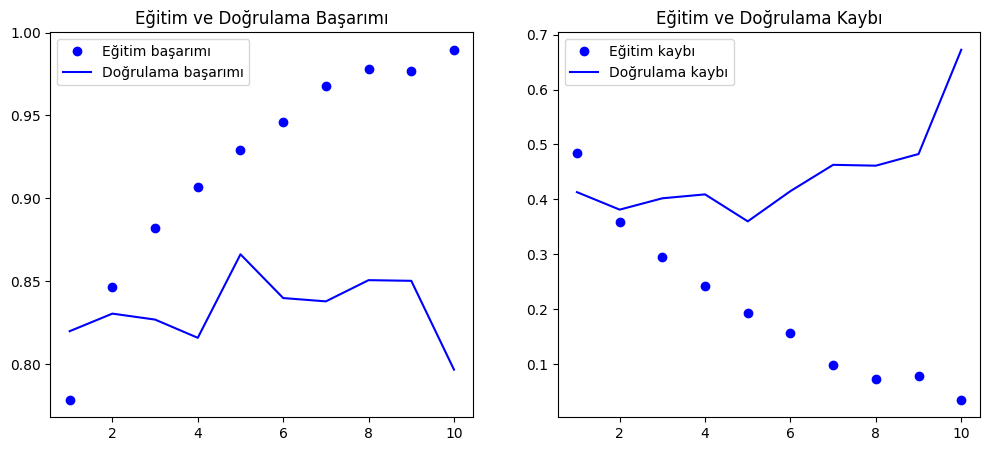

In [ ]:
import matplotlib.pyplot as plt

# 1. Eğitim ve Doğrulama Sonuçlarını Görselleştirme
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Eğitim başarımı')
plt.plot(epochs, val_acc, 'b', label='Doğrulama başarımı')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.legend()

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Eğitim kaybı')
plt.plot(epochs, val_loss, 'b', label='Doğrulama kaybı')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


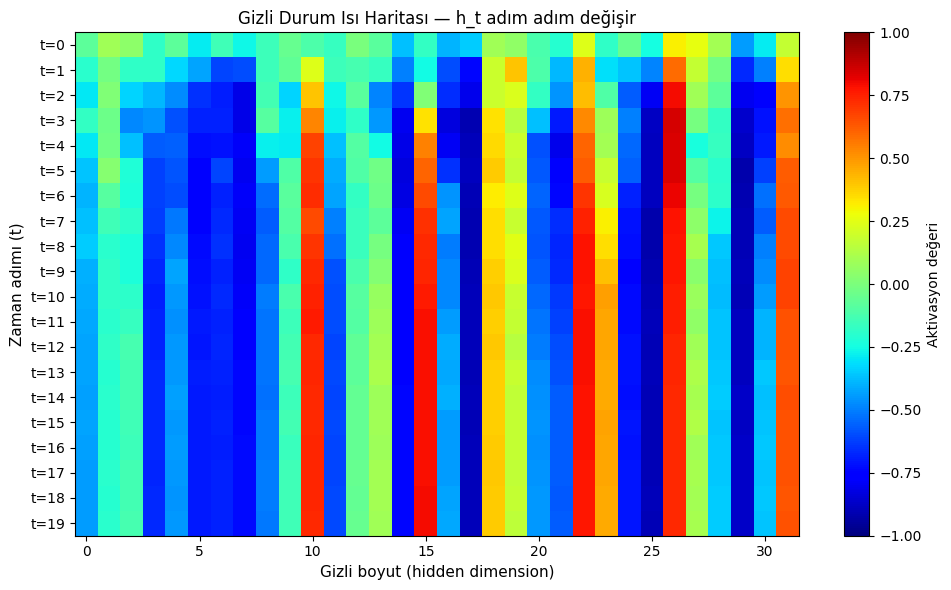

Isı haritası başarıyla oluşturuldu ✓


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ADIM 1: Gizli Durumları Çıkaracak Bir "Görselleştirme Modeli" Kuralım ---
# Mevcut modelindeki katmanları kullanarak ara çıktıları (RNN katmanını) alıyoruz
# Not: RNN katmanının tüm zaman adımlarını döndürmesi gerekir (return_sequences=True)
vis_model = Sequential()
vis_model.add(Embedding(max_features, 32)) # input_length is deprecated, removed it.
# Eğitimdeki ağırlıkları korumak için orijinal modelin ağırlıklarını transfer edebiliriz
# ya da sadece yapıyı anlamak için yeni bir katman gibi düşünebilirsin.
vis_model.add(SimpleRNN(32, return_sequences=True))

# Explicitly build the model to initialize its weights before transferring
vis_model.build(input_shape=(None, maxlen))

vis_model.set_weights(model.get_weights()[:4]) # İlk iki katmanın ağırlıklarını kopyala

# --- ADIM 2: Bir Test Verisi Seçelim ve Tahmin Yapalım ---
sample_idx = 0 # İlk yorumu inceleyelim
sample_input = x_test[sample_idx:sample_idx+1] # (1, 500) boyutunda
activations = vis_model.predict(sample_input) # Çıktı: (1, 500, 32) -> (örnek, zaman, gizli_birim)

# --- ADIM 3: Hocanın Verdiği Kod Yapısına Uyarlayalım ---
SEQ_LEN = 20 # Karmaşıklığı önlemek için ilk 20 kelimeye/adımına bakalım
H = activations[0, :SEQ_LEN, :] # (20, 32) boyutunda matris

fig, ax = plt.subplots(figsize=(10, 6)) # Boyutu biraz artırdım daha net görünmesi için
im = ax.imshow(H, aspect="auto", cmap="jet", vmin=-1, vmax=1)

ax.set_xlabel("Gizli boyut (hidden dimension)", fontsize=11)
ax.set_ylabel("Zaman adımı (t)", fontsize=11)
ax.set_title("Gizli Durum Isı Haritası — h_t adım adım değişir", fontsize=12)

ax.set_yticks(range(SEQ_LEN))
ax.set_yticklabels([f"t={i}" for i in range(SEQ_LEN)])

plt.colorbar(im, ax=ax, label="Aktivasyon değeri")
plt.tight_layout()
# plt.savefig("/tmp/rnn_heatmap.png", dpi=120, bbox_inches="tight") # Bilgisayarında bu yol yoksa hata verebilir
plt.show()

print("Isı haritası başarıyla oluşturuldu ✓")